# Week 5: AI-Assisted Triage: Data Exploration (Part 1 of 2)

## 1. Setup

In [1]:
# Run this cell first.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Let pandas show more of a wide table when printing
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

print("Environment ready · pandas", pd.__version__)

Environment ready · pandas 2.2.2


## 2. Load data

In [2]:
DATA_PATH = Path("yaleemmlc_admissionprediction_triage.csv")

df = pd.read_csv(DATA_PATH, index_col=0)   # index_col=0 drops the unnamed export index
print(f"Loaded real dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")

df.head()

Loaded real dataset: 55,121 rows x 225 columns


,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,insurance_status,disposition,arrivalmode,arrivalmonth,arrivalday,arrivalhour_bin,previousdispo,triage_vital_hr,triage_vital_sbp,triage_vital_dbp,triage_vital_rr,triage_vital_o2,triage_vital_o2_device,triage_vital_temp,triage_glucose,cc_abdominalcramping,cc_abdominaldistention,cc_abdominalpain,cc_abdominalpainpregnant,cc_abnormallab,...,cc_sorethroat,cc_stdcheck,cc_strokealert,cc_suicidal,cc_suture/stapleremoval,cc_swallowedforeignbody,cc_syncope,cc_tachycardia,cc_testiclepain,cc_thumbinjury,cc_tickremoval,cc_toeinjury,cc_toepain,cc_trauma,cc_unresponsive,cc_uri,cc_urinaryfrequency,cc_urinaryretention,cc_urinarytractinfection,cc_vaginalbleeding,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,Retired,Medicare,Discharge,Car,March,Saturday,11-14,Admit,88.0,155.0,75.0,17.0,98.0,0.0,97.8,87.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17,B,2.0,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,Disabled,Medicare,Admit,Walk-in,September,Monday,11-14,Discharge,118.0,105.0,79.0,20.0,98.0,0.0,97.5,113.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
40,A,2.0,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,Full Time,Commercial,Discharge,ambulance,June,Tuesday,15-18,Admit,76.0,116.0,71.0,18.0,99.0,0.0,98.1,108.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
47,A,3.0,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,Full Time,Commercial,Discharge,Car,April,Sunday,23-02,Discharge,106.0,103.0,63.0,16.0,97.0,0.0,98.2,85.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
60,A,2.0,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,Not Employed,Medicaid,Discharge,ambulance,July,Wednesday,23-02,Discharge,84.0,109.0,68.0,18.0,95.0,0.0,97.8,88.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3. Shape and structural overview

Chief-complaint flags (`cc_*`) are complete-by-design 0/1 indicators, not free-standing measurements, so we separate them from the **structured** clinical/demographic columns before profiling missingness and types. Otherwise approximately 200 always-populated flag columns would drown out the columns that actually have gaps.

In [3]:
structured = [c for c in df.columns if not c.startswith("cc_")]
cc_flags   = [c for c in df.columns if c.startswith("cc_")]

print("Shape:", df.shape)
print(f"Structured columns: {len(structured)}   Chief-complaint flags: {len(cc_flags)}\n")
print("Column types at a glance:")
print(df.dtypes.value_counts())

Shape: (55121, 225)
Structured columns: 25   Chief-complaint flags: 200

Column types at a glance:
float64    210
object      15
Name: count, dtype: int64


**CLINICAL CONTEXT:** This is a **wide, sparse** dataset: most columns describe a single encounter thinly (one chief-complaint flag fires per patient), while a small core of demographic and vital-sign columns carries most of the analytical weight. Structural summaries below focus on that structured core.

## 4. `.info()` - Structural snapshot

In [4]:
df[structured].info()

<class 'pandas.core.frame.DataFrame'>
Index: 55121 entries, 7 to 433332
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   dep_name                55121 non-null  object 
 1   esi                     55121 non-null  float64
 2   age                     55121 non-null  float64
 3   gender                  55121 non-null  object 
 4   ethnicity               55121 non-null  object 
 5   race                    55121 non-null  object 
 6   lang                    55121 non-null  object 
 7   religion                55121 non-null  object 
 8   maritalstatus           55121 non-null  object 
 9   employstatus            55121 non-null  object 
 10  insurance_status        55121 non-null  object 
 11  disposition             55121 non-null  object 
 12  arrivalmode             55121 non-null  object 
 13  arrivalmonth            55121 non-null  object 
 14  arrivalday              55121 non-null  ob

`.info()` gives, per column: its dtype and its count of **non-null** values. So, any column whose non-null count is below the total row count already flags itself as incomplete here.

## 5. `.describe()` - Numeric and categorical summaries

In [5]:
numeric_cols = df[structured].select_dtypes(include="number").columns.tolist()
print("Numeric columns:")
df[numeric_cols].describe().round(2)

Numeric columns:


,esi,age,triage_vital_hr,triage_vital_sbp,triage_vital_dbp,triage_vital_rr,triage_vital_o2,triage_vital_o2_device,triage_vital_temp,triage_glucose
count,55121.00,55121.00,55121.00,55121.00,55121.00,55121.00,55121.00,55121.00,55121.00,55121.00
mean,2.88,55.32,86.45,133.68,79.53,17.84,97.02,0.07,98.09,130.09
std,0.75,19.54,16.96,22.65,14.59,2.07,2.08,0.25,0.81,73.66
min,1.00,18.00,32.00,53.00,27.00,8.00,62.00,0.00,91.50,16.00
25%,2.00,40.00,74.00,118.00,70.00,16.00,96.00,0.00,97.70,93.00
50%,3.00,55.00,85.00,132.00,79.00,18.00,98.00,0.00,98.00,107.00
75%,3.00,70.00,97.00,147.00,89.00,18.00,98.00,0.00,98.40,134.00
max,5.00,107.00,221.00,266.00,189.00,66.00,99.00,1.00,106.00,1066.00


In [6]:
cat_cols = [c for c in structured if c not in numeric_cols]
print("Categorical / text columns:")
df[cat_cols].describe()

Categorical / text columns:


,dep_name,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,insurance_status,disposition,arrivalmode,arrivalmonth,arrivalday,arrivalhour_bin,previousdispo
count,55121,55121,55121,55121,55121,55121,55121,55121,55121,55121,55121,55121,55121,55121,55121
unique,3,2,4,8,2,12,10,10,5,2,7,12,7,6,10
top,A,Female,Non-Hispanic,White or Caucasian,English,Catholic,Single,Retired,Medicaid,Discharge,Car,June,Monday,11-14,Discharge
freq,34933,31744,45142,29435,50264,23550,22901,17058,21427,34565,22797,5987,8687,15872,28627


For categorical columns, `.describe()` reports `count` (non-null rows), `unique` (distinct categories), and the most frequent category with its frequency (`top` / `freq`), the categorical equivalent of mean/median for a number column.

## 6. Missing values

**ANALYTICAL NOTE:** A raw count of missing cells is hard to interpret on its own. Reporting **both** the count and the percentage keeps the audit honest and comparable across datasets.

In [8]:
missing_count = df[structured].isna().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct":   missing_pct,
    "dtype":         df[structured].dtypes.astype(str),
})
missing_report = missing_report[missing_report["missing_count"] > 0].sort_values("missing_pct", ascending=False)

print(f"{len(missing_report)} of {len(structured)} structured columns have at least one missing value.\n")
missing_report

0 of 25 structured columns have at least one missing value.



,missing_count,missing_pct,dtype


## 7. Data type audit

Two failure modes matter here: a column that **should** be numeric but was read as text (often because of a stray unit suffix or a free-text placeholder like "NR"), and a column that **is** numeric but actually encodes a small set of categories (a code, not a quantity). Both silently break downstream statistics and models if left unflagged.

In [9]:
audit_rows = []

# (a) object/text columns that are mostly parseable as numbers
for col in structured:
    if pd.api.types.is_object_dtype(df[col]) or pd.api.types.is_string_dtype(df[col]):
        non_null = df[col].dropna()
        if len(non_null) == 0:
            continue
        parse_rate = pd.to_numeric(non_null, errors="coerce").notna().mean()
        if parse_rate > 0.9:
            audit_rows.append({
                "column": col, "current_dtype": "object",
                "issue": "numeric stored as text",
                "parseable_pct": round(parse_rate * 100, 1),
                "unique_values": np.nan,
            })

# (b) numeric columns with very few distinct values -> behaves like a category, not a quantity
for col in structured:
    if pd.api.types.is_numeric_dtype(df[col]):
        nun = df[col].nunique(dropna=True)
        if nun <= 5:
            audit_rows.append({
                "column": col, "current_dtype": str(df[col].dtype),
                "issue": "numeric but behaves like a category",
                "parseable_pct": np.nan,
                "unique_values": nun,
            })

dtype_audit = pd.DataFrame(audit_rows)
dtype_audit

,column,current_dtype,issue,parseable_pct,unique_values
0,esi,float64,numeric but behaves like a category,NaN,5
1,triage_vital_o2_device,float64,numeric but behaves like a category,NaN,2


## 8. Missingness visualisation

/tmp/ipykernel_2493/113252659.py:8: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


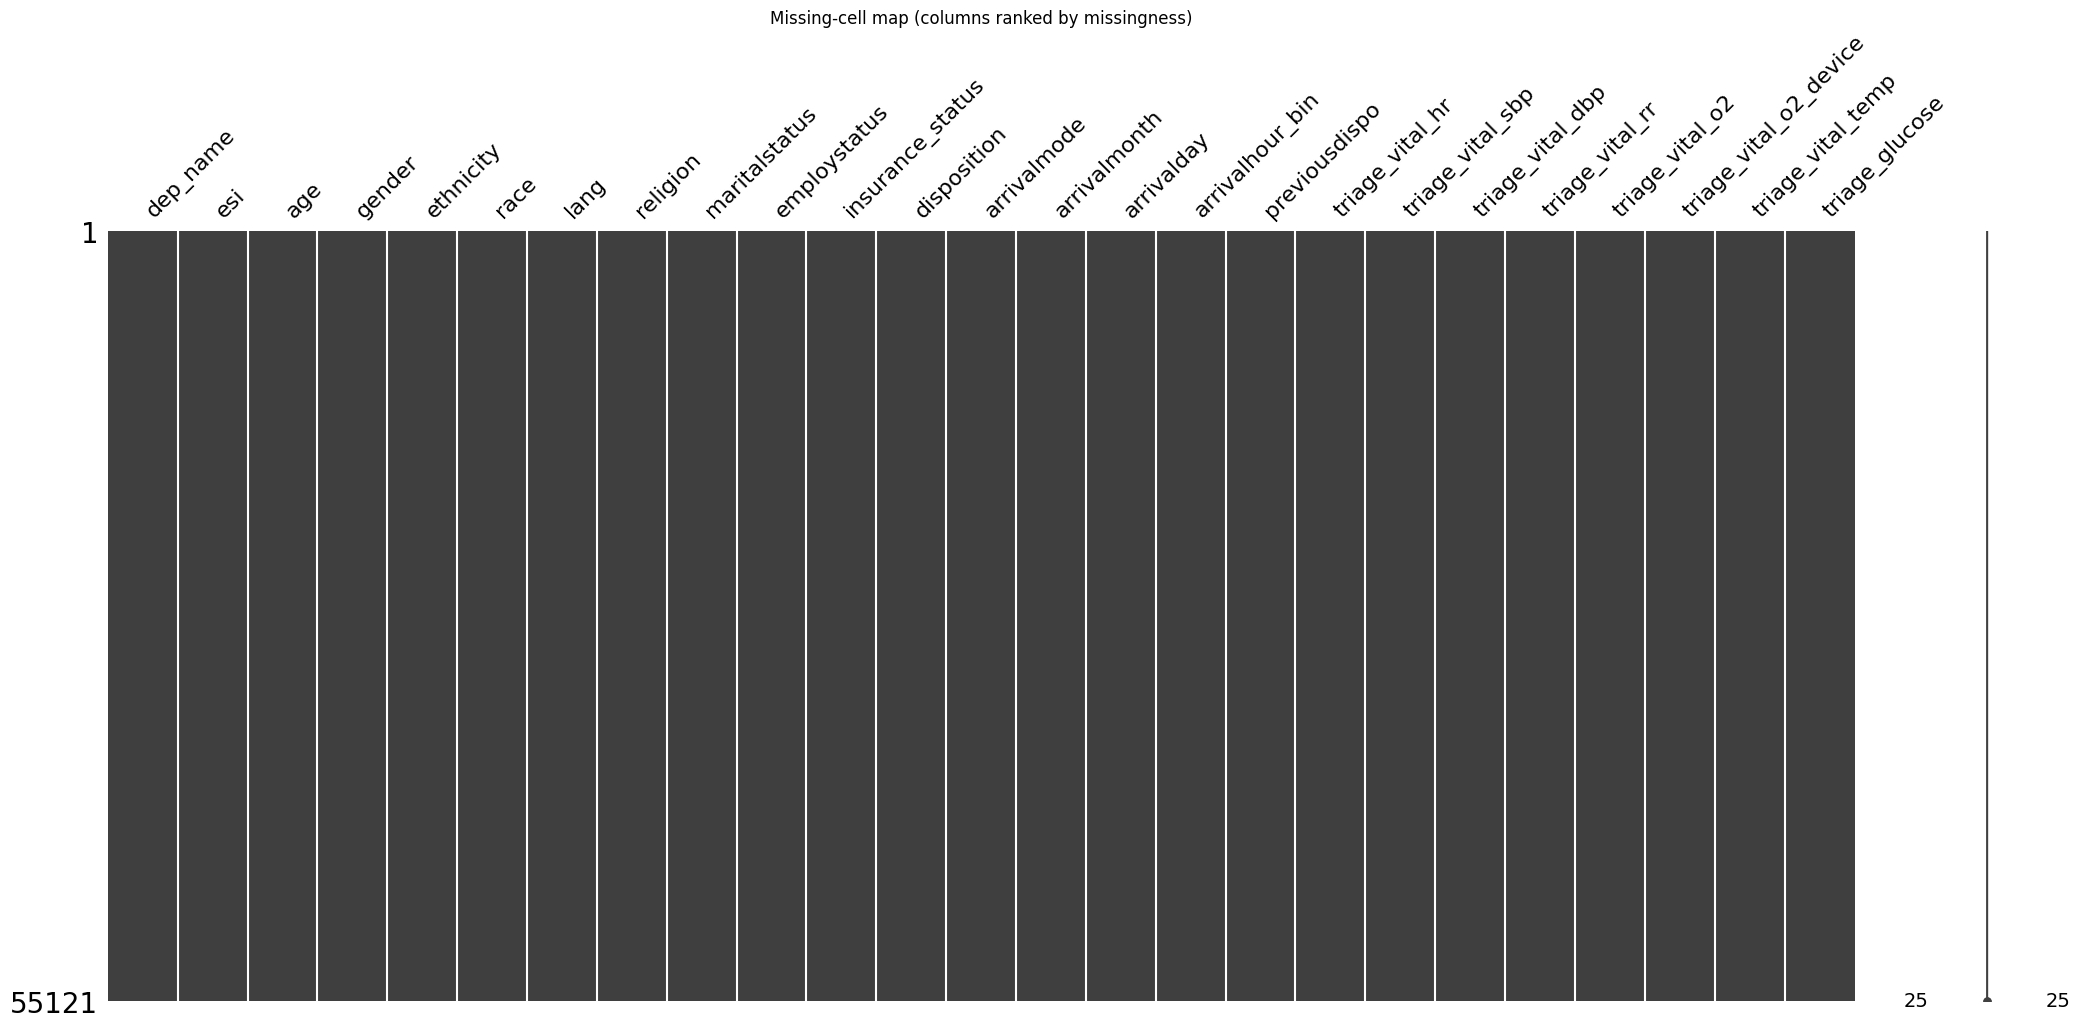

In [14]:
# Missing-cell map, columns ordered worst-missing first
ordered_cols = missing_report.index.tolist() + [c for c in structured if c not in missing_report.index]

try:
    import missingno as msno
    msno.matrix(df[ordered_cols])
    plt.title("Missing-cell map (columns ranked by missingness)")
    plt.tight_layout()
    plt.savefig("figs/missingness_matrix.png", dpi=150)
    plt.show()
except ImportError:
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.imshow(df[ordered_cols].isna().values, aspect="auto", cmap="gray_r", interpolation="nearest")
    ax.set_xticks(range(len(ordered_cols)))
    ax.set_xticklabels(ordered_cols, rotation=90, fontsize=8)
    ax.set_yticks([])
    ax.set_title("Missing-cell map (dark = missing) — columns ranked by missingness", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig("figs/missingness_matrix.png", dpi=150)
    plt.show()

## 9. Data-quality summary

In [15]:
issues = []
for col, row in missing_report.iterrows():
    severity = "high" if row["missing_pct"] >= 25 else ("moderate" if row["missing_pct"] >= 10 else "low")
    issues.append({
        "column": col,
        "missing_pct": row["missing_pct"],
        "severity": severity,
        "suggested_action": "review for drop / imputation strategy" if severity != "low" else "monitor",
    })
for _, r in dtype_audit.iterrows():
    issues.append({
        "column": r["column"],
        "missing_pct": np.nan,
        "severity": "dtype",
        "suggested_action": r["issue"],
    })

quality_summary = pd.DataFrame(issues)
quality_summary

,column,missing_pct,severity,suggested_action
0,esi,NaN,dtype,numeric but behaves like a category
1,triage_vital_o2_device,NaN,dtype,numeric but behaves like a category


## 10. Wrap-up

This notebook has measured: shape, dtypes, descriptive statistics, per-column missingness (counts and percentages), a dtype-inconsistency audit, and an exported missingness visualisation (`figs/missingness_matrix.png`).